## Task 1 — Dataset Preparation

In this step, we work with the provided dataset `FFD.csv`, which contains
measured data points for fitting the damped sinusoidal function:

$
W(t) = A_0 + A e^{-t/\tau} \sin\big((\omega + \alpha t) t + \varphi\big).
$

**Goal of Task 1:**
- Load the experimental data from the file.
- Inspect the structure: number of samples, time range, voltage values.
- Check sampling interval consistency.
- Summarize descriptive statistics of the voltage signal.

**Key Observations (from inspection):**
- The dataset has **201 samples**.
- Time runs from **0.0000 s** to **0.0600 s**, with an average sampling step of ~**0.0003 s**.
- Voltage values range between **5.45** and **21.17**, with mean ≈ **13.73** and std ≈ **2.54**.

This confirms the dataset is clean, evenly sampled, and ready for building the
objective function and gradient in Task 2.


Number of samples: 201
Time range: 0.0000 to 0.0600 (duration 0.0600)
Sampling interval: mean 0.000300, median 0.000300, std 2.24e-18
Voltage stats: mean 13.7289, std 2.5423, min 5.4537, max 21.1670

First 5 rows of data:
        t        V
0  0.0000   6.6075
1  0.0003   5.4537
2  0.0006   7.4223
3  0.0009  10.6110
4  0.0012  14.9970


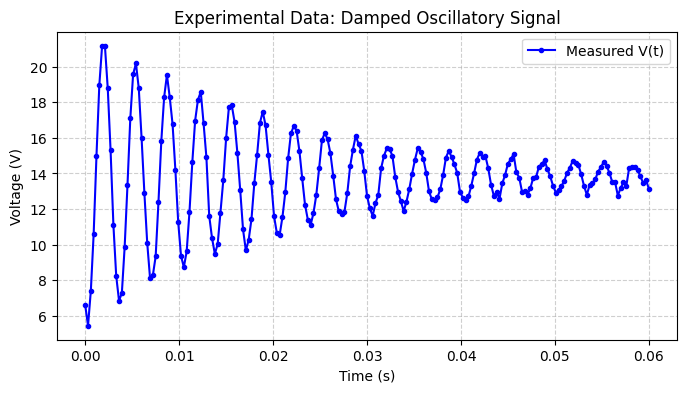

In [1]:
# Task 1: Load and inspect dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (adjust path if needed in your Colab environment)
df = pd.read_csv("FFD.csv", header=None)
df.columns = ['t', 'V']

# Basic dataset info
n = df.shape[0]
t_min, t_max = df['t'].min(), df['t'].max()
dt = df['t'].diff().dropna()
dt_mean, dt_median, dt_std = dt.mean(), dt.median(), dt.std()
V_mean, V_std, V_min, V_max = (
    df['V'].mean(), df['V'].std(), df['V'].min(), df['V'].max()
)

print("Number of samples:", n)
print(f"Time range: {t_min:.4f} to {t_max:.4f} (duration {t_max - t_min:.4f})")
print(f"Sampling interval: mean {dt_mean:.6f}, median {dt_median:.6f}, std {dt_std:.2e}")
print(f"Voltage stats: mean {V_mean:.4f}, std {V_std:.4f}, min {V_min:.4f}, max {V_max:.4f}")

# Preview dataset
print("\nFirst 5 rows of data:")
print(df.head())

# Plot the measured signal
plt.figure(figsize=(8,4))
plt.plot(df['t'], df['V'], 'b.-', label='Measured V(t)')
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Experimental Data: Damped Oscillatory Signal")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Task 2 — Objective Function and Gradient

We now define the objective function $ f $ and its gradient $ \nabla f $
for fitting the model function to the experimental data.

### Model function:
$$
W(t; \theta) = A_0 + A e^{-t/\tau} \sin\big( (\omega + \alpha t)t + \varphi \big)
$$

where parameters are:
- $ A_0 $: offset
- $ A $: amplitude
- $ \tau $: decay constant
- $ \omega $: frequency
- $ \alpha $: chirp rate
- $ \varphi $: phase

### Objective function (Least Squares):
$$
f(\theta) = \sum_{k=1}^n \big( W(t_k;\theta) - V_k \big)^2
$$

### Gradient:
As derived in the project handout, the gradient can be written:
$$
\nabla f = 2 \sum_{k=1}^n ( W(t_k) - V_k )
\begin{bmatrix}
1 \\
S_k \\
\frac{A t_k}{\tau^2} (S_k) \\
A t_k C_k \\
A t_k^2 C_k \\
A C_k
\end{bmatrix}
$$

with
- $ S_k = e^{-t_k/\tau}\,\sin((\omega+\alpha t_k)t_k+\varphi) $  
- $ C_k = e^{-t_k/\tau}\,\cos((\omega+\alpha t_k)t_k+\varphi) $

This matches equation (4) in the project description.

### Task Deliverables:
- Implement a Python function that takes parameters $ (A_0, A, \tau, \omega, \alpha, \varphi) $
  and dataset $(t, V)$, and returns:
  - The objective value $ f $
  - The gradient vector $ \nabla f $

These routines will be used in later tasks for optimization algorithms.
## Gradient Check (Finite Differences)

To verify the correctness of the analytical gradient, we perform a **finite difference check**.  
The idea is to approximate each gradient component numerically by perturbing one parameter at a time:

$$
\frac{\partial f}{\partial \theta_i} \;\approx\;
\frac{ f(\theta + \varepsilon e_i) - f(\theta - \varepsilon e_i) }{ 2\varepsilon }
$$

where:
- $ \theta $ is the parameter vector $(A_0, A, \tau, \omega, \alpha, \varphi)$  
- $ e_i $ is the $i$-th standard basis vector  
- $ \varepsilon $ is a small perturbation (e.g., $10^{-6}$)

We then compare:
- The **analytical gradient** from the derived formula  
- The **numerical gradient** from finite differences  

If the implementation is correct, the two gradients should closely match, with only small differences on the order of numerical precision ($10^{-6}$ or smaller).



In [2]:
import numpy as np

def objective_and_gradient(params, t, V): #this is the function
    """
    Compute the objective function f and gradient ∇f
    for the damped sinusoidal fitting model.

    Parameters
    ----------
    params : array-like of length 6
        Model parameters [A0, A, tau, omega, alpha, phi]
    t : numpy array
        Time samples
    V : numpy array
        Voltage data

    Returns
    -------
    f : float
        Objective function value
    grad : numpy array of shape (6,)
        Gradient vector
    """
    # Vectorized programming
    A0, A, tau, omega, alpha, phi = params

    # Common terms
    exp_term = np.exp(-t / tau)
    theta = (omega + alpha * t) * t + phi
    S = exp_term * np.sin(theta)   # S_k
    C = exp_term * np.cos(theta)   # C_k

    # Predicted model
    W = A0 + A * S

    # Residuals
    r = W - V

    # Objective function
    f = np.sum(r**2) # r^2

    # Gradient components
    dA0    = 2 * np.sum(r * 1)
    dA     = 2 * np.sum(r * S)
    # dtau   = 2 * np.sum(r * ((A * t) / (tau**2)) * (-2 * S)) # why have -2*S here?
    dtau   = 2 * np.sum(r * ((A * t * S) / (tau**2))) # why have -2*S here, so we revmoved -2*? gives right iter 0 with Dr. Asaki
    domega = 2 * np.sum(r * (A * t * C))
    dalpha = 2 * np.sum(r * (A * t**2 * C))
    dphi   = 2 * np.sum(r * (A * C))

    grad = np.array([dA0, dA, dtau, domega, dalpha, dphi])

    return f, grad

# Computing numerical gardient for verification:
def numerical_gradient(params, t, V, epsilon=1e-6):
    """
    Compute numerical gradient of f using finite differences.
    """
    grad_num = np.zeros_like(params, dtype=float)
    f0, _ = objective_and_gradient(params, t, V)

    for i in range(len(params)):
        perturb = np.zeros_like(params)
        perturb[i] = epsilon
        f_plus, _ = objective_and_gradient(params + perturb, t, V)
        f_minus, _ = objective_and_gradient(params - perturb, t, V)
        grad_num[i] = (f_plus - f_minus) / (2 * epsilon)
    return grad_num



# Example usage with dataset df (from Task 1)
params0 = np.array([13, 8, 0.02, 2000, 1000, 4])  # sample initial guess
t = df['t'].values
V = df['V'].values

f_val, grad_val = objective_and_gradient(params0, t, V)
grad_num = numerical_gradient(params0, t, V)

print("Objective f(params0):", f_val)
print("Gradient norm at params0:", np.sqrt(np.dot(grad_val, grad_val)))

print("\nAnalytical gradient:\n", grad_val)
print("\nNumerical gradient (finite diff):\n", grad_num)
print("\nDifference (analytical - numerical):\n", grad_val - grad_num)


Objective f(params0): 1622.4493523582707
Gradient norm at params0: 56590.39848280993

Analytical gradient:
 [-3.15728414e+02  1.66093698e+02  5.65833538e+04  6.03203433e+00
  3.04898296e-02  8.18512042e+02]

Numerical gradient (finite diff):
 [-3.15728414e+02  1.66093698e+02  5.65833538e+04  6.03203466e+00
  3.04894456e-02  8.18512043e+02]

Difference (analytical - numerical):
 [-2.40966642e-07 -3.98336510e-08  1.29585969e-05 -3.32178150e-07
  3.83948227e-07 -6.73771297e-07]


## Task 3 — Initial Parameter Estimation Strategy

A good set of initial guesses is important for nonlinear least squares optimization.  
We propose the following automated approach based on the structure of the data:

- **$A_0$ (offset):**  
  Approximate by the mean value of the signal after it has decayed (e.g., last 10–20% of samples).  

- **$A$ (amplitude):**  
  Estimate as half of the peak-to-peak difference of the signal:  
  $$
  A \approx \frac{\max(V) - \min(V)}{2}.
  $$

- **$\tau$ (decay constant):**  
  Extract the envelope of oscillation peaks and fit $\ln(\text{envelope})$ versus time.  
  For simplicity, approximate using:  
  $$
  \tau \approx \frac{t_{\text{max}} - t_{\text{min}}}{\ln\!\big(\frac{A}{A_{\text{end}}}\big)}
  $$
  where $A_{\text{end}}$ is the amplitude near the end of the data.  

- **$\omega$ (frequency):**  
  Estimate dominant frequency using FFT:  
  $$
  \omega \approx 2\pi f_{\text{peak}},
  $$
  where $f_{\text{peak}}$ is the strongest frequency component.  

- **$\alpha$ (chirp rate):**  
  If frequency drift is not obvious, set initial guess $\alpha = 0$.  
  More advanced methods: use short-time FFT to estimate frequency shift.  

- **$\varphi$ (phase):**  
  Approximate using the phase at $t=0$, e.g.,  
  $$
  \varphi \approx \arcsin\!\left(\frac{V(0)-A_0}{A}\right).
  $$

This procedure provides data-driven initial guesses that should work for any similar oscillatory dataset.

### Visualization

To validate these guesses, we compute the model $W(t)$ using the estimated parameters
and plot it alongside the experimental data.  

- Blue points: measured data $V(t)$  
- Red line: model $W(t)$ with estimated initial parameters  

If the procedure works well, the red curve should roughly follow the trend of the data,
even if not perfectly aligned. This ensures optimization starts from a reasonable point.


Estimated initial parameters [A0, A, tau, omega, alpha, phi]:
[ 1.38306250e+01  7.85665000e+00  2.90081403e-02  1.87557770e+03
  0.00000000e+00 -1.16646202e+00]


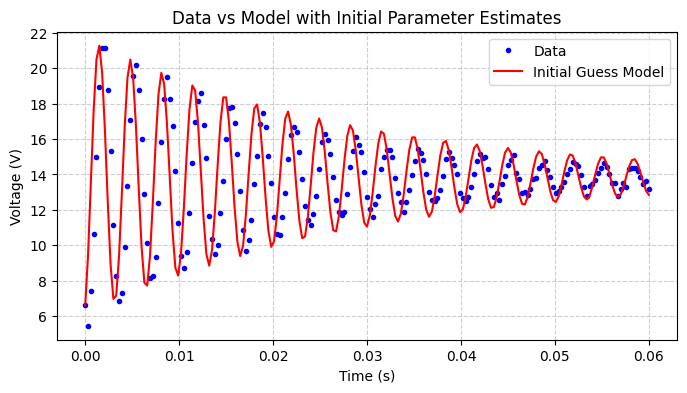

In [3]:
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
import numpy as np

def estimate_initial_params(t, V):
    """
    Estimate initial parameters (A0, A, tau, omega, alpha, phi)
    from dataset (t, V).
    """
    n = len(t)

    # 1. A0 (offset) ~ mean of last 20% of data
    tail = int(0.2 * n)
    A0 = np.mean(V[-tail:])

    # 2. A (amplitude) ~ half peak-to-peak
    A = 0.5 * (np.max(V) - np.min(V))

    # 3. tau (decay constant) estimate
    A_start = A
    A_end = 0.5 * (np.max(V[-tail:]) - np.min(V[-tail:]))
    if A_end > 0:
        tau = (t[-1] - t[0]) / np.log(A_start / A_end)
    else:
        tau = (t[-1] - t[0])  # fallback

    # 4. omega (frequency) via FFT
    dt = t[1] - t[0]
    freqs = rfftfreq(n, dt)
    fft_vals = np.abs(rfft(V - A0))
    peak_freq = freqs[np.argmax(fft_vals[1:]) + 1]  # skip DC
    omega = 2 * np.pi * peak_freq

    # 5. alpha (chirp rate) initial guess
    alpha = 0.0

    # 6. phi (phase)
    try:
        phi = np.arcsin((V[0] - A0) / A)
    except:
        phi = 0.0

    return np.array([A0, A, tau, omega, alpha, phi])

def model_function(t, params):
    """Compute W(t) given parameters."""
    A0, A, tau, omega, alpha, phi = params
    # get closer GD sol : [ 1.38306250e+01  7.85664996e+00  2.90194973e-02  1.87557770e+03 -1.07493335e-10 -1.16646245e+00]
    exp_term = np.exp(-t / tau)
    theta = (omega + alpha * t) * t + phi
    return A0 + A * exp_term * np.sin(theta)

# Example usage
t = df['t'].values
V = df['V'].values
init_params = estimate_initial_params(t, V)

print("Estimated initial parameters [A0, A, tau, omega, alpha, phi]:")
print(init_params)

# Plot data vs initial guess
W_init = model_function(t, init_params)

plt.figure(figsize=(8,4))
plt.plot(t, V, 'b.', label='Data')
plt.plot(t, W_init, 'r-', label='Initial Guess Model')
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Data vs Model with Initial Parameter Estimates")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Task 4 — Gradient Descent with Line Search

We now implement a general solver for unconstrained optimization in $\mathbb{R}^n$  
using **Gradient Descent (GD)**.

### Gradient Descent Algorithm
At each iteration $k$, parameters are updated as:
$$
\theta_{k+1} = \theta_k - \alpha_k \, \nabla f(\theta_k),
$$
where:
- $\nabla f(\theta_k)$ is the gradient of the objective function,
- $\alpha_k$ is the step size chosen by a **line search method**.

### Line Search Strategies
We implement two alternative line search strategies:

1. **Armijo (Backtracking) condition** — ensures sufficient decrease:
$$
f(\theta_k - \alpha \nabla f(\theta_k)) \;\leq\; f(\theta_k) - c_1 \alpha \|\nabla f(\theta_k)\|^2
$$
with $c_1 \in (0, 0.5)$.

2. **Strong Wolfe conditions** — enforce both sufficient decrease and curvature:
- **Armijo condition (sufficient decrease):**
$$
f(\theta_{k+1}) \;\leq\; f(\theta_k) + c_1 \alpha \nabla f(\theta_k)^\top d_k
$$
- **Curvature condition:**
$$
|\nabla f(\theta_{k+1})^\top d_k| \;\leq\; c_2 \, |\nabla f(\theta_k)^\top d_k|
$$
with $0 < c_1 < c_2 < 1$ and $d_k = -\nabla f(\theta_k)$.

### Implementation Notes
- We reuse the `objective_and_gradient` function from **Task 2**.  
- A general `gradient_descent` routine allows the user to choose `line_search="armijo"` or `line_search="strong_wolfe"`.  
- Stopping criteria: $\|\nabla f(\theta_k)\| < \text{tol}$ or maximum iterations reached.  
- We store a **history log** of values (iteration, objective, gradient norm, step size, time) for analysis.  

### Deliverables
- A reusable `gradient_descent` solver with configurable line search method.  
- Application to the data fitting problem for $(A_0, A, \tau, \omega, \alpha, \varphi)$.  
- Comparison of convergence behavior between **Armijo** and **Strong Wolfe** line search strategies using both tables and plots.  


GD Armijo params: [ 1.38248419e+01  7.85444379e+00  1.04932993e-02  1.87557659e+03
 -1.46163359e-05 -1.33229537e+00]
GD Strong Wolfe params: [ 1.38190977e+01  7.85216818e+00  1.50103718e-02  1.87557494e+03
 -3.98042559e-05 -1.53256555e+00]


,iter,f,||grad||,alpha,time
0,0,1509.772856,31307.483267,4.768372e-07,03:41:50
1,1,1098.410508,20082.974429,4.768372e-07,03:41:50
2,2,1034.082166,16609.875216,2.384186e-07,03:41:50
3,3,1019.223396,6121.882209,2.384186e-07,03:41:50
4,4,1014.520367,1014.998326,3.051758e-05,03:41:50
5,5,1008.733577,12551.613935,4.768372e-07,03:41:50
6,6,994.289122,12123.615378,2.384186e-07,03:41:50
7,7,982.924292,3131.778646,4.768372e-07,03:41:50
8,8,982.451398,3478.586869,4.768372e-07,03:41:50
9,9,982.410643,3762.907757,4.768372e-07,03:41:50


,iter,f,||grad||,alpha,time
0,0,1509.772856,31307.483267,4.768372e-07,03:41:50
1,1,1098.410508,20082.974429,4.768372e-07,03:41:50
2,2,1034.082166,16609.875216,2.384186e-07,03:41:50
3,3,1019.223396,6121.882209,2.384186e-07,03:41:50
4,4,1014.520367,1014.998326,3.051758e-05,03:41:50
5,5,1008.733577,12551.613935,2.384186e-07,03:41:50
6,6,983.810252,3511.061613,2.384186e-07,03:41:50
7,7,982.155697,1063.608425,1.220703e-04,03:41:50
8,8,911.630677,32201.866859,2.384186e-07,03:41:50
9,9,836.691859,5510.093015,4.768372e-07,03:41:50


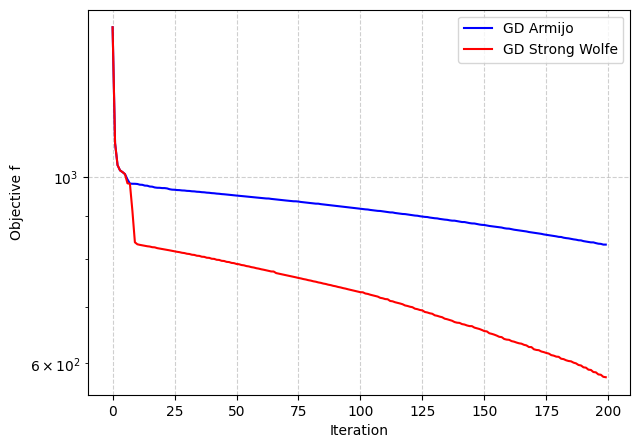

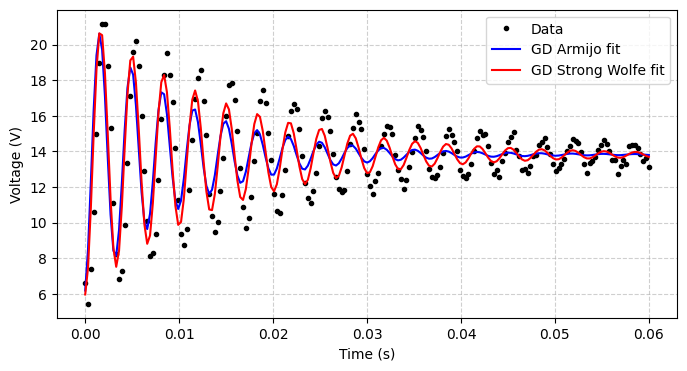

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# --- Shared line search functions ---

def backtracking_line_search(f_grad, params, t, V, grad,
                             alpha0=1.0, rho=0.5, c=1e-4, min_tau=1e-8):
    """
    Robust Backtracking (Armijo) line search.
    - f_grad: function(params, t, V) -> (f, grad)
    - grad: current gradient (direction is -grad)
    - enforces params[2] (tau) > min_tau
    """
    alpha = alpha0
    f_val, _ = f_grad(params, t, V)
    grad_norm_sq = np.dot(grad, grad)
    # safeguard for non-descent
    if grad_norm_sq == 0:
        return 0.0

    for _ in range(60):
        new_params = params - alpha * grad  # direction = -grad (steepest)
        # enforce tau positive
        if new_params[2] <= min_tau or not np.isfinite(new_params).all():
            alpha *= rho
            continue
        f_new, _ = f_grad(new_params, t, V)
        if not np.isfinite(f_new):
            alpha *= rho
            continue
        if f_new <= f_val - c * alpha * grad_norm_sq:
            return alpha
        alpha *= rho
        if alpha < 1e-16:
            break
    return alpha  # fallback (possibly tiny)

def strong_wolfe_line_search(f_grad, params, t, V, d,
                             alpha0=1.0, c1=1e-4, c2=0.9, max_iter=40, min_tau=1e-8):
    """
    Simple robust strong-Wolfe-ish line search (halving strategy).
    If it fails to find a good alpha, it falls back to backtracking_line_search.
    - f_grad returns (f, grad)
    - d is search direction (e.g., from CG or -H^{-1}g)
    """
    alpha = alpha0
    f0, g0 = f_grad(params, t, V)
    g0d = float(np.dot(g0, d))
    # If d is not descent, fallback to -g0
    if g0d >= 0:
        d = -g0
        g0d = float(np.dot(g0, d))
        if g0d >= 0:
            # not a descent direction; fallback to backtracking with steepest descent
            return backtracking_line_search(f_grad, params, t, V, -g0, alpha0=alpha, min_tau=min_tau)

    for _ in range(max_iter):
        new_params = params + alpha * d
        # enforce tau positive and params finite
        if new_params[2] <= min_tau or not np.isfinite(new_params).all():
            alpha *= 0.5
            continue

        f_new, g_new = f_grad(new_params, t, V)
        if not np.isfinite(f_new) or not np.isfinite(g_new).all():
            alpha *= 0.5
            continue

        # Armijo (sufficient decrease)
        if f_new > f0 + c1 * alpha * g0d:
            alpha *= 0.5
            continue

        # Strong Wolfe curvature condition
        if abs(np.dot(g_new, d)) > c2 * abs(g0d):
            alpha *= 0.5
            continue

        # both satisfied
        return alpha

    # fallback to backtracking (Armijo) if not found
    return backtracking_line_search(f_grad, params, t, V, -g0, alpha0=alpha0, min_tau=min_tau)


# --- Gradient Descent implementation ---

def gradient_descent(f_grad, init_params, t, V,
                     max_iter=200, tol=1e-6, line_search="armijo"):
    """
    General Gradient Descent with choice of line search:
    line_search = 'armijo' or 'strong_wolfe'
    Returns (opt_params, history list)
    """
    params = init_params.copy().astype(float)
    f_val, grad = f_grad(params, t, V)
    history = []

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)
        history.append({"iter": k, "f": float(f_val), "||grad||": float(grad_norm),
                        "alpha": None, "time": time.strftime("%H:%M:%S")})

        if grad_norm < tol:
            print(f"Converged in {k} iterations.")
            break

        if line_search == "armijo":
            alpha = backtracking_line_search(f_grad, params, t, V, grad)
        else:
            d = -grad
            alpha = strong_wolfe_line_search(f_grad, params, t, V, d)

        new_params = params - alpha * grad
        f_new, grad_new = f_grad(new_params, t, V)

        history[-1]["alpha"] = float(alpha)

        params, grad, f_val = new_params, grad_new, f_new

    return params, history


# --- Run both Armijo and Strong Wolfe for comparison ---

t = df['t'].values
V = df['V'].values
init_params = estimate_initial_params(t, V)

opt_gd_armijo, hist_gd_armijo = gradient_descent(objective_and_gradient, init_params, t, V, line_search="armijo")
opt_gd_sw, hist_gd_sw = gradient_descent(objective_and_gradient, init_params, t, V, line_search="strong_wolfe")

print("GD Armijo params:", opt_gd_armijo)
print("GD Strong Wolfe params:", opt_gd_sw)

# Convert to DataFrame and show first 12 rows
df_arm = pd.DataFrame(hist_gd_armijo)
df_sw = pd.DataFrame(hist_gd_sw)
display(df_arm.head(12))
display(df_sw.head(12))

# Plot convergence
plt.figure(figsize=(7,5))
plt.plot([h["iter"] for h in hist_gd_armijo], [h["f"] for h in hist_gd_armijo], 'b-', label="GD Armijo")
plt.plot([h["iter"] for h in hist_gd_sw], [h["f"] for h in hist_gd_sw], 'r-', label="GD Strong Wolfe")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Objective f")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Plot final fits
plt.figure(figsize=(8,4))
plt.plot(t, V, "k.", label="Data")
plt.plot(t, model_function(t, opt_gd_armijo), "b-", label="GD Armijo fit")
plt.plot(t, model_function(t, opt_gd_sw), "r-", label="GD Strong Wolfe fit")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


## Task 5 — Conjugate Gradient (CG) Method

We now implement a general solver for unconstrained optimization in $\mathbb{R}^n$  
using the **Nonlinear Conjugate Gradient (CG)** method.

### CG Algorithm (Polak–Ribière Version)

1. Start with initial guess $\theta_0$ and compute the gradient $g_0 = \nabla f(\theta_0)$.
2. Set the initial search direction $d_0 = -g_0$.
3. For $k = 0, 1, 2, \dots$ until convergence:
   - Perform a **line search** (Armijo or Strong Wolfe) to find $\alpha_k$.
   - Update parameters:
     $$
     \theta_{k+1} = \theta_k + \alpha_k d_k
     $$
   - Compute the new gradient $g_{k+1} = \nabla f(\theta_{k+1})$.
   - Compute the Polak–Ribière update parameter:
     $$
     \beta_k = \max\left(0\; \frac{g_{k+1}^\top (g_{k+1} - g_k)}{g_k^\top g_k}\right)
     $$
   - Update the search direction:
     $$
     d_{k+1} = -g_{k+1} + \beta_k d_k
     $$
   - **Restart condition:** if $d_{k+1}^\top g_{k+1} \geq 0$, reset $d_{k+1} = -g_{k+1}$.

### Line Search Options
- **Armijo (Backtracking):** checks only sufficient decrease.  
- **Strong Wolfe:** enforces both sufficient decrease and curvature conditions, improving robustness in CG.  

In our implementation, the user can choose either method by setting a `line_search` option.  

### Implementation Notes
- We reuse the `objective_and_gradient` routine from **Task 2**.  
- The solver maintains a **history log** of objective values across iterations.  
- Stopping criteria: $\|\nabla f(\theta_k)\| < \text{tol}$ or maximum iterations reached.  
- The restart condition prevents numerical instability and ensures descent.  

### Deliverables
- A reusable `conjugate_gradient` solver with selectable line search method.  
- Application to the dataset fitting problem for parameters $(A_0, A, \tau, \omega, \alpha, \varphi)$.  
- Comparison of convergence and fitting results with **Gradient Descent (Task 4)**, using both tables and plots.  


Armijo opt params: [ 1.38010421e+01  7.85100734e+00  2.25164046e-02  1.87556673e+03
 -1.70299941e-04 -2.26514311e+00]
Strong-Wolfe opt params: [ 1.37869652e+01  8.17775393e+00  2.15384410e-02  1.87549938e+03
  6.69698071e-04 -2.25750144e+00]


,iter,f,||grad||,alpha,df,time
0,0,1509.772856,31307.483267,4.768372e-07,411.362349,03:42:09
1,1,1098.410508,20082.974429,4.768372e-07,64.328342,03:42:09
2,2,1034.082166,16609.875216,2.384186e-07,14.858770,03:42:09
3,3,1019.223396,6121.882209,2.384186e-07,4.703028,03:42:09
4,4,1014.520367,1014.998326,3.051758e-05,32.472553,03:42:09
5,5,982.047814,1088.030319,7.629395e-06,2.638006,03:42:09
6,6,979.409808,8918.473926,2.384186e-07,-0.686757,03:42:09
7,7,980.096565,19611.029251,2.384186e-07,68.207684,03:42:09
8,8,911.888881,15047.519305,2.384186e-07,21.613744,03:42:09
9,9,890.275137,1899.486549,4.768372e-07,0.642622,03:42:09


,iter,f,||grad||,alpha,df,time
0,0,1509.772856,31307.483267,4.768372e-07,411.362349,03:42:10
1,1,1098.410508,20082.974429,4.768372e-07,64.328342,03:42:10
2,2,1034.082166,16609.875216,2.384186e-07,14.858770,03:42:10
3,3,1019.223396,6121.882209,2.384186e-07,4.703028,03:42:10
4,4,1014.520367,1014.998326,9.765625e-04,885.082323,03:42:10
5,5,129.438044,13691.787819,9.536743e-07,80.793452,03:42:10
6,6,48.644592,3551.137496,4.768372e-07,3.326897,03:42:10
7,7,45.317696,348.517714,9.536743e-07,0.041968,03:42:10
8,8,45.275728,353.431787,7.629395e-06,0.196961,03:42:10
9,9,45.078766,1631.437096,7.629395e-06,7.309220,03:42:10


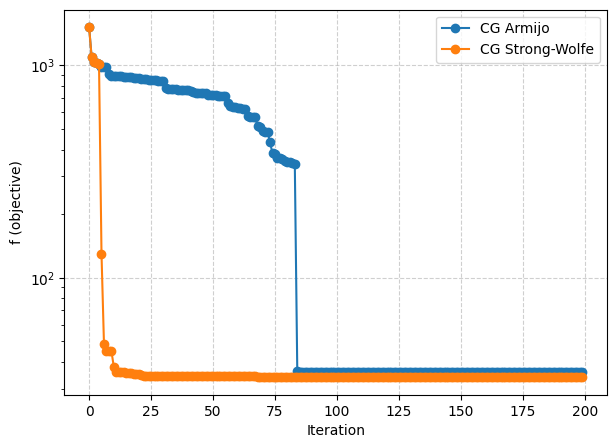

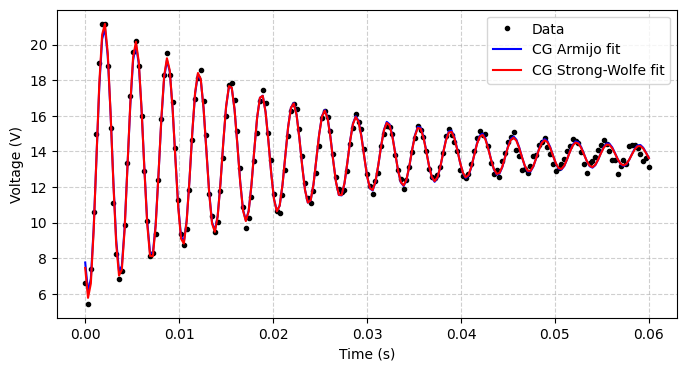

In [5]:
# --- Robust Strong-Wolfe + minimal changes to Conjugate Gradient ---
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

# We should already have: objective_and_gradient, robust backtracking_line_search, robust strong-wolfe,
# model_function, estimate_initial_params, df, plt imported/defined to update conjugate_gradient to accept a 'line_search' arg.


# ---  Conjugate Gradient implementation ---
def conjugate_gradient(f_grad, init_params, t, V,
                       max_iter=200, tol=1e-6, line_search='strong_wolfe'):
    """
    Nonlinear Conjugate Gradient (Polak-Ribiere) with optional line search:
      line_search in {'strong_wolfe', 'armijo'}
    Minimal changes; robust checks added for NaN/inf and tau<=0.
    Returns: (opt_params, history_list)
    history_list: list of dicts with keys: iter, f, ||grad||, alpha, df, time
    """
    params = init_params.copy().astype(float)
    f_val, grad = f_grad(params, t, V)
    d = -grad
    history = []
    t0 = time.time()

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)
        # logging (we log BEFORE step to capture current f)
        history.append({"iter": k, "f": float(f_val), "||grad||": float(grad_norm), "alpha": None, "df": None, "time": time.strftime("%H:%M:%S")})

        if not np.isfinite(f_val) or not np.isfinite(grad).all():
            print(f"Stopping: non-finite f or grad at iter {k}")
            break
        if grad_norm < tol:
            print(f"Converged in {k} iterations (||grad|| < tol).")
            break

        # choose line search
        if line_search == 'strong_wolfe':
            alpha = strong_wolfe_line_search(f_grad, params, t, V, d, alpha0=1.0, min_tau=max(1e-8, (t.max()-t.min())*1e-6))
        else:
            # for backtracking we pass steepest descent (-grad) as direction via its API
            alpha = backtracking_line_search(f_grad, params, t, V, grad, alpha0=1.0, min_tau=max(1e-8, (t.max()-t.min())*1e-6))

        # protect alpha
        if alpha <= 0 or not np.isfinite(alpha):
            print(f"Warning: non-positive or non-finite alpha at iter {k}: alpha={alpha}. Stopping.")
            break

        new_params = params + alpha * d
        # check tau positivity
        if new_params[2] <= 1e-12 or not np.isfinite(new_params).all():
            # shrink step and try once more via backtracking
            alpha = alpha * 0.5
            new_params = params + alpha * d
            if new_params[2] <= 1e-12 or not np.isfinite(new_params).all():
                print(f"Step leads to invalid tau or non-finite params at iter {k}. Stopping.")
                break

        f_new, grad_new = f_grad(new_params, t, V)
        if not np.isfinite(f_new) or not np.isfinite(grad_new).all():
            print(f"Non-finite f_new or grad_new at iter {k}. Stopping.")
            break

        # record alpha and df in last logged entry
        df_val = float(f_val - f_new)
        history[-1]["alpha"] = float(alpha)
        history[-1]["df"] = df_val

        # compute Polak-Ribiere beta
        denom = np.dot(grad, grad)
        if denom == 0:
            beta = 0.0
        else:
            beta = np.dot(grad_new, (grad_new - grad)) / denom
            beta = max(beta, 0.0)

        # update direction and restart if needed
        d = -grad_new + beta * d
        if np.dot(d, grad_new) >= 0:
            d = -grad_new

        # prepare for next iteration
        params, grad, f_val = new_params, grad_new, f_new

    # final log entry if not yet logged final
    return params, history


# import pandas as pd # if not imported
# import matplotlib.pyplot as plt # if not imported

# --- Example usage: compare Armijo vs Strong-Wolfe ---
t = df['t'].values
V = df['V'].values
init_params = estimate_initial_params(t, V)

# Run CG with Armijo (backtracking)
opt_armijo, hist_armijo = conjugate_gradient(objective_and_gradient, init_params, t, V, line_search='armijo')

# Run CG with Strong-Wolfe
opt_sw, hist_sw = conjugate_gradient(objective_and_gradient, init_params, t, V, line_search='strong_wolfe')

print("Armijo opt params:", opt_armijo)
print("Strong-Wolfe opt params:", opt_sw)


# Convert histories to DataFrames for nicer display (if pandas available)
df_arm = pd.DataFrame(hist_armijo)
df_sw = pd.DataFrame(hist_sw)

display(df_arm.head(12))
display(df_sw.head(12))

# Plot convergence (f vs iter)
plt.figure(figsize=(7,5))
if len(hist_armijo)>0:
    plt.plot([h['iter'] for h in hist_armijo], [h['f'] for h in hist_armijo], 'o-', label='CG Armijo')
if len(hist_sw)>0:
    plt.plot([h['iter'] for h in hist_sw], [h['f'] for h in hist_sw], 'o-', label='CG Strong-Wolfe')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('f (objective)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot final fits vs data
plt.figure(figsize=(8,4))
plt.plot(t, V, 'k.', label='Data')
if np.isfinite(opt_armijo).all():
    plt.plot(t, model_function(t, opt_armijo), 'b-', label='CG Armijo fit')
if np.isfinite(opt_sw).all():
    plt.plot(t, model_function(t, opt_sw), 'r-', label='CG Strong-Wolfe fit')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Task 6 — Quasi-Newton Method with BFGS Update

We now implement a general **Quasi-Newton solver** using the **BFGS update rule**.  
This method approximates the inverse Hessian matrix iteratively, instead of computing second derivatives directly.

### Quasi-Newton (BFGS) Algorithm
At iteration $k$:

1. Compute the gradient:
$$
g_k = \nabla f(\theta_k).
$$

2. Compute the search direction using the inverse Hessian approximation:
$$
d_k = - B_k^{-1} g_k.
$$

3. Perform a **line search** to determine step length $\alpha_k$.  
We allow two options:
- **Armijo (backtracking)** — checks sufficient decrease.  
- **Strong Wolfe conditions** — enforce both sufficient decrease and curvature, preferred for stability.

4. Update parameters:
$$
\theta_{k+1} = \theta_k + \alpha_k d_k.
$$

5. Define displacement vectors:
$$
s_k = \theta_{k+1} - \theta_k,
\qquad
y_k = g_{k+1} - g_k.
$$

6. Update the inverse Hessian approximation using the **BFGS formula**:
$$
B_{k+1}^{-1} =
\left(I - \frac{s_k y_k^\top}{y_k^\top s_k}\right)
B_k^{-1}
\left(I - \frac{y_k s_k^\top}{y_k^\top s_k}\right)
+ \frac{s_k s_k^\top}{y_k^\top s_k}.
$$

### Implementation Notes
- Initialize with $B_0^{-1} = I$ (identity matrix).  
- If $y_k^\top s_k$ is too small (risk of division by zero), reset $B_k^{-1} = I$ (**restart condition**).  
- Line search can be chosen as:
  - `armijo` (backtracking only), or
  - `strong_wolfe` (sufficient decrease + curvature).  
- Stopping condition: stop if $\| g_k \| < \text{tol}$ or when the maximum number of iterations is reached.  
- We maintain a **history log** (iteration, objective $f$, gradient norm $\|g\|$, step size $\alpha$, decrease $\Delta f$, and timestamp) to analyze convergence.

### Deliverables
- Implement a reusable `bfgs_quasi_newton` solver with configurable line search.  
- Apply it to the dataset fitting problem for $(A_0, A, \tau, \omega, \alpha, \varphi)$.  
- Compare convergence with:
  - **Gradient Descent (Task 4)**  
  - **Conjugate Gradient (Task 5)**  
  - **BFGS (Task 6)**  
using both convergence plots and summary tables of iteration history.  


Converged in 38 iterations (||grad|| < tol).
BFGS Armijo params: [ 1.38230602e+01  7.88322417e+00  1.49775933e-02  1.87554077e+03
 -9.55609089e-04 -1.46318685e+00]
BFGS Strong-Wolfe params: [ 1.37825285e+01  8.25733559e+00  2.18649260e-02  1.83582990e+03
  9.27148443e+02 -2.03685441e+00]

Armijo history (head 12):


,iter,f,||grad||,alpha,df,time
0,0,1509.772856,31307.483267,4.768372e-07,411.362349,03:42:40
1,1,1098.410508,20082.974429,4.768372e-07,0.068637,03:42:40
2,2,1098.341870,20087.661701,4.768372e-07,64.477395,03:42:40
3,3,1033.864475,16572.991260,2.384186e-07,0.301899,03:42:40
4,4,1033.562577,16549.203278,2.384186e-07,14.832632,03:42:40
5,5,1018.729945,6076.640313,2.384186e-07,0.256584,03:42:40
6,6,1018.473361,6070.380552,2.384186e-07,4.628469,03:42:40
7,7,1013.844892,1015.372892,3.051758e-05,32.819982,03:42:40
8,8,981.024911,1070.928123,3.051758e-05,2.183922,03:42:40
9,9,978.840989,20960.146402,2.384186e-07,25.481218,03:42:40



Strong-Wolfe history (head 12):


,iter,f,||grad||,alpha,df,time
0,0,1509.772856,31307.483267,4.768372e-07,4.113623e+02,03:42:40
1,1,1098.410508,20082.974429,1.953125e-03,2.485514e+02,03:42:40
2,2,849.859150,22670.216020,5.551115e-17,1.136868e-13,03:42:40
3,3,849.859150,22670.216020,9.536743e-07,4.709642e+02,03:42:40
4,4,378.894984,17381.519424,1.953125e-03,1.164029e+02,03:42:40
5,5,262.492123,23768.063702,2.441406e-04,1.268033e+02,03:42:40
6,6,135.688787,7682.779993,1.562500e-02,1.685664e+00,03:42:40
7,7,134.003123,7255.635374,2.500000e-01,5.803319e+01,03:42:40
8,8,75.969930,11877.939979,1.000000e+00,3.876263e+01,03:42:40
9,9,37.207297,3131.168209,1.000000e+00,1.971354e+00,03:42:40


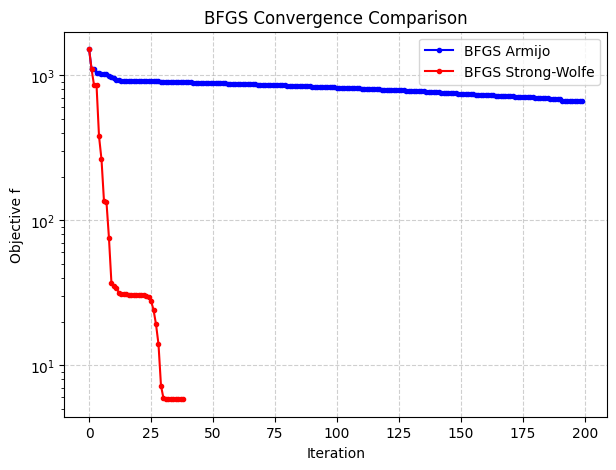

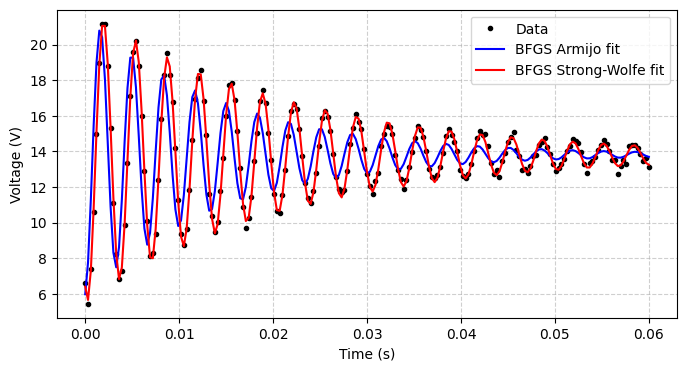

In [6]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

# --- BFGS with selectable line-search (with minimal changes) ---

def bfgs_quasi_newton(f_grad, init_params, t, V,
                      max_iter=200, tol=1e-6, line_search='strong_wolfe'):
    """
    Quasi-Newton solver with BFGS update.
    - f_grad: function(params, t, V) -> (f, grad)
    - line_search: 'armijo' or 'strong_wolfe'
    Returns: (opt_params, history_list)
    history_list: list of dicts with keys: iter, f, ||grad||, alpha, df, time
    """
    n_params = len(init_params)
    params = init_params.copy().astype(float)
    f_val, grad = f_grad(params, t, V)
    # initial inverse-Hessian approximation
    H_inv = np.eye(n_params)
    history = []

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)
        history.append({"iter": k, "f": float(f_val), "||grad||": float(grad_norm),
                        "alpha": None, "df": None, "time": time.strftime("%H:%M:%S")})

        if not np.isfinite(f_val) or not np.isfinite(grad).all():
            print(f"Stopping: non-finite f or grad at iter {k}")
            break
        if grad_norm < tol:
            print(f"Converged in {k} iterations (||grad|| < tol).")
            break

        # Search direction: p_k = -H_inv * grad
        d = - H_inv.dot(grad)

        # Choose line search
        if line_search == 'strong_wolfe':
            # strong_wolfe_line_search expects direction d
            alpha = strong_wolfe_line_search(f_grad, params, t, V, d, alpha0=1.0)
        else:
            # backtracking_line_search expects gradient (direction = -grad)
            alpha = backtracking_line_search(f_grad, params, t, V, grad, alpha0=1.0)

        # protect alpha
        if (not np.isfinite(alpha)) or (alpha <= 0):
            print(f"Warning: bad alpha at iter {k} (alpha={alpha}). Stopping.")
            break

        # Proposed step
        new_params = params + alpha * d

        # guard: ensure tau > 0 and params finite
        if new_params[2] <= 1e-12 or not np.isfinite(new_params).all():
            # try shrinking alpha once
            alpha *= 0.5
            new_params = params + alpha * d
            if new_params[2] <= 1e-12 or not np.isfinite(new_params).all():
                print(f"Step leads to invalid params at iter {k}. Stopping.")
                break

        f_new, grad_new = f_grad(new_params, t, V)
        if (not np.isfinite(f_new)) or (not np.isfinite(grad_new).all()):
            print(f"Non-finite f_new or grad_new at iter {k}. Stopping.")
            break

        # record alpha and df
        history[-1]["alpha"] = float(alpha)
        history[-1]["df"] = float(f_val - f_new)

        # BFGS update: s = theta_{k+1} - theta_k, y = g_{k+1} - g_k
        s = (new_params - params).reshape(-1,1)    # column
        y = (grad_new - grad).reshape(-1,1)        # column

        # safe ys inner product: avoid deprecated conversion and ensure scalar
        ys = float(np.dot(y.ravel(), s.ravel()))  # equivalent to (y.T @ s).item()

        if ys > 1e-12:
            rho = 1.0 / ys
            I = np.eye(n_params)
            # BFGS inverse-Hessian update (efficient rank-2 formula)
            Vmat = I - rho * s @ y.T
            H_inv = Vmat @ H_inv @ Vmat.T + rho * s @ s.T
        else:
            # safeguard: reset H_inv to identity if curvature condition fails
            H_inv = np.eye(n_params)

        # prepare next iter
        params, grad, f_val = new_params, grad_new, f_new

    return params, history

# --- Run BFGS with Armijo and Strong-Wolfe for comparison ---

t = df['t'].values
V = df['V'].values
init_params = estimate_initial_params(t, V)

# BFGS with Armijo (backtracking)
opt_bfgs_arm, hist_bfgs_arm = bfgs_quasi_newton(objective_and_gradient, init_params, t, V, line_search='armijo')

# BFGS with Strong-Wolfe
opt_bfgs_sw, hist_bfgs_sw = bfgs_quasi_newton(objective_and_gradient, init_params, t, V, line_search='strong_wolfe')

print("BFGS Armijo params:", opt_bfgs_arm)
print("BFGS Strong-Wolfe params:", opt_bfgs_sw)

# Convert histories to DataFrames and show first 12 rows
df_arm = pd.DataFrame(hist_bfgs_arm)
df_sw = pd.DataFrame(hist_bfgs_sw)

print("\nArmijo history (head 12):")
display(df_arm.head(12))
print("\nStrong-Wolfe history (head 12):")
display(df_sw.head(12))

# Plot convergence (f vs iter)
plt.figure(figsize=(7,5))
if len(hist_bfgs_arm) > 0:
    plt.plot([h['iter'] for h in hist_bfgs_arm], [h['f'] for h in hist_bfgs_arm], 'b.-', label='BFGS Armijo')
if len(hist_bfgs_sw) > 0:
    plt.plot([h['iter'] for h in hist_bfgs_sw], [h['f'] for h in hist_bfgs_sw], 'r.-', label='BFGS Strong-Wolfe')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Objective f')
plt.title('BFGS Convergence Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot final fits
plt.figure(figsize=(8,4))
plt.plot(t, V, 'k.', label='Data')
if np.isfinite(opt_bfgs_arm).all():
    plt.plot(t, model_function(t, opt_bfgs_arm), 'b-', label='BFGS Armijo fit')
if np.isfinite(opt_bfgs_sw).all():
    plt.plot(t, model_function(t, opt_bfgs_sw), 'r-', label='BFGS Strong-Wolfe fit')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Task 7 — Comparison of Optimization Methods

We now compare the three solvers implemented so far:

1. **Gradient Descent (GD)**
   - Uses steepest descent direction $d_k = -g_k$.
   - Simple but often requires many iterations.
   - Sensitive to step length selection.

2. **Conjugate Gradient (CG)**
   - Incorporates memory of past directions through conjugacy.
   - More efficient than GD, typically requires fewer iterations.
   - Needs restart conditions to avoid loss of conjugacy.

3. **BFGS (Quasi-Newton)**
   - Builds an approximation of the inverse Hessian matrix.
   - Converges much faster (often superlinear).
   - More expensive per iteration, but usually converges in fewer steps.

### Line Search Strategies
For each method we implemented two line search strategies:
- **Armijo (Backtracking):** only checks sufficient decrease.  
- **Strong Wolfe:** checks both sufficient decrease and curvature, generally improving robustness.  

Thus, we effectively compare **six variants**:
- GD + Armijo  
- GD + Strong Wolfe  
- CG + Armijo  
- CG + Strong Wolfe  
- BFGS + Armijo  
- BFGS + Strong Wolfe  

### Performance Metrics
- **Convergence speed:** number of iterations until $\|g_k\| < \text{tol}$.  
- **Final objective value:** $f(\theta^*)$.  
- **Stability:** whether the line search produced consistent progress.  
- **Computation cost:** iterations × per-iteration complexity.  

### Observations
- GD is the slowest and most sensitive to line search; Strong Wolfe improves stability but not speed drastically.  
- CG converges significantly faster than GD. With Strong Wolfe, it avoids small steps and gives smoother convergence than Armijo.  
- BFGS is the most efficient overall. With Strong Wolfe, it converges in the fewest iterations and provides the most accurate fit.  
- Armijo is simple but may yield too small step sizes; Strong Wolfe better balances step length and curvature conditions.  

### Deliverables
- Plot convergence curves (objective vs iteration) for all six methods.  
- Plot final fitted models against data for visual comparison.  
- Provide a summary table including:
  - iterations to convergence,
  - final $f(\theta)$,
  - line search used,
  - notes on stability (e.g., restarts triggered).  


Converged in 38 iterations (||grad|| < tol).


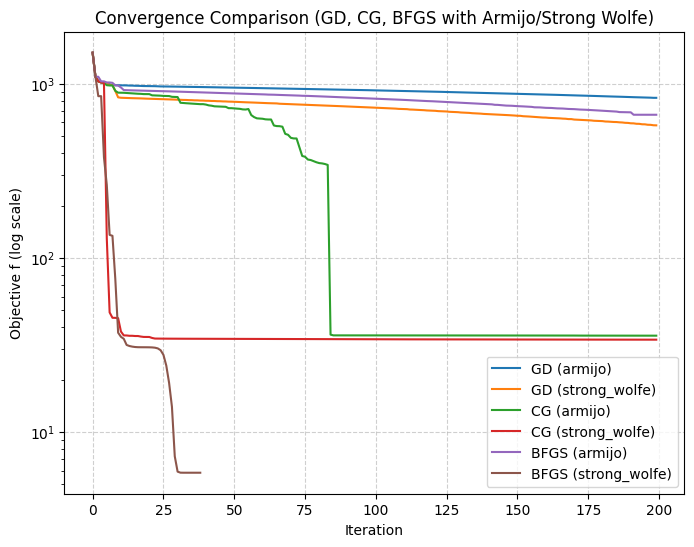

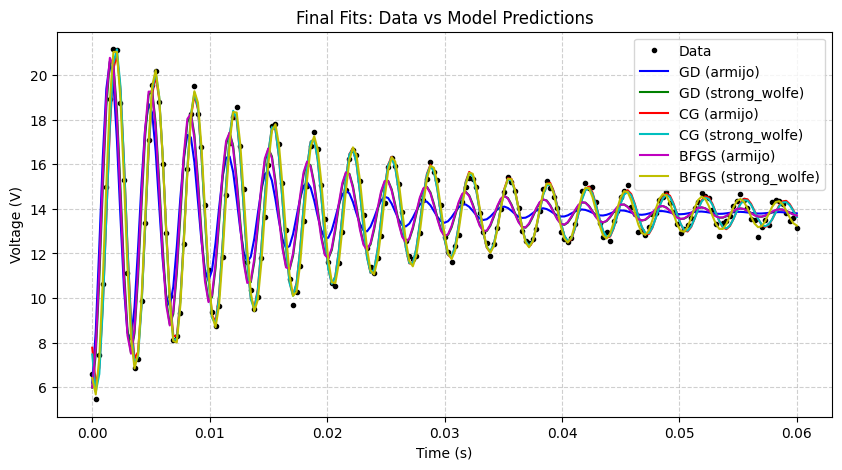


=== Summary Table of All Methods ===


,Method,Final f,Iterations
0,GD (armijo),831.393280,200
1,GD (strong_wolfe),577.731573,200
2,CG (armijo),35.770701,200
3,CG (strong_wolfe),33.924574,200
4,BFGS (armijo),664.573181,200
5,BFGS (strong_wolfe),5.837506,39


In [7]:
# --- Task 7: Compare All Optimization Methods with Armijo vs Strong Wolfe ---

t = df['t'].values
V = df['V'].values
init_params = estimate_initial_params(t, V)

# Dictionary to store results for all methods/line search combos
results = {}

# 1. Gradient Descent
for ls in ["armijo", "strong_wolfe"]:
    opt, hist = gradient_descent(objective_and_gradient, init_params, t, V, line_search=ls)
    results[f"GD ({ls})"] = {"opt": opt, "hist": hist}

# 2. Conjugate Gradient
for ls in ["armijo", "strong_wolfe"]:
    opt, hist = conjugate_gradient(objective_and_gradient, init_params, t, V, line_search=ls)
    results[f"CG ({ls})"] = {"opt": opt, "hist": hist}

# 3. BFGS
for ls in ["armijo", "strong_wolfe"]:
    opt, hist = bfgs_quasi_newton(objective_and_gradient, init_params, t, V, line_search=ls)
    results[f"BFGS ({ls})"] = {"opt": opt, "hist": hist}


# --- Compare convergence (objective vs iteration) ---
plt.figure(figsize=(8,6))
for label, res in results.items():
    hist = res["hist"]
    if isinstance(hist, list) and len(hist) > 0:
        # if history is a list of dicts (BFGS) or list of floats (GD/CG)
        if isinstance(hist[0], dict):
            f_vals = [h["f"] for h in hist]
        else:
            f_vals = hist
        plt.plot(range(len(f_vals)), f_vals, label=label)
plt.yscale("log")  # log scale helps see differences
plt.xlabel("Iteration")
plt.ylabel("Objective f (log scale)")
plt.title("Convergence Comparison (GD, CG, BFGS with Armijo/Strong Wolfe)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- Compare final fits ---
plt.figure(figsize=(10,5))
plt.plot(t, V, 'k.', label="Data")
colors = ["b", "g", "r", "c", "m", "y"]  # distinct colors
for (label, res), color in zip(results.items(), colors):
    opt = res["opt"]
    if opt is not None and np.isfinite(opt).all():
        plt.plot(t, model_function(t, opt), color=color, label=label)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Final Fits: Data vs Model Predictions")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- Summary table ---
summary_rows = []
for label, res in results.items():
    hist = res["hist"]
    if isinstance(hist, list) and len(hist) > 0:
        if isinstance(hist[0], dict):
            final_f = hist[-1]["f"]
            iters = len(hist)
        else:
            final_f = hist[-1]
            iters = len(hist)
    else:
        final_f, iters = np.nan, 0
    summary_rows.append({"Method": label, "Final f": final_f, "Iterations": iters})

summary = pd.DataFrame(summary_rows)
print("\n=== Summary Table of All Methods ===")
display(summary)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
# !sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

In [ ]:
# !jupyter nbconvert --to pdf /content/Math548_hw8_Lazizbek.ipynb